## Setup

### Imports

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Loading Dataset

In [2]:
feature_df = pd.read_csv('./dataset/ai_productivity_features.csv')
target_df  = pd.read_csv('./dataset/ai_productivity_targets.csv')

## Clean Data

In [3]:
full_df = pd.merge(feature_df, target_df, on="Employee_ID")

### Sanity Checks

In [4]:
#checks: data types, non null counts, basic statistics (min, max, mean...)
full_df.info()
full_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   4500 non-null   object 
 1   job_role                      4500 non-null   object 
 2   experience_years              4500 non-null   int64  
 3   ai_tool_usage_hours_per_week  4500 non-null   float64
 4   tasks_automated_percent       4500 non-null   float64
 5   manual_work_hours_per_week    4500 non-null   float64
 6   learning_time_hours_per_week  4500 non-null   float64
 7   deadline_pressure_level       4500 non-null   object 
 8   meeting_hours_per_week        4500 non-null   float64
 9   collaboration_hours_per_week  4500 non-null   float64
 10  error_rate_percent            4500 non-null   float64
 11  task_complexity_score         4500 non-null   int64  
 12  focus_hours_per_day           4500 non-null   float64
 13  wor

,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score,productivity_score
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,10.427556,10.349667,25.908467,22.372867,2.001756,6.571089,8.249311,2.097044,5.507556,4.694489,4.724689,8.354816,64.946600
std,5.745073,5.808240,15.157930,6.465516,1.408176,4.683117,3.040733,1.519145,2.861737,1.337197,1.993201,1.813773,14.297129
min,1.000000,0.000000,0.000000,10.000000,0.000000,1.000000,2.000000,0.100000,1.000000,1.000000,1.000000,3.220000,20.500000
25%,6.000000,6.000000,14.500000,17.900000,1.000000,3.400000,6.200000,0.710000,3.000000,3.900000,3.300000,6.850000,54.975000
50%,10.000000,9.700000,24.500000,22.500000,1.700000,5.700000,8.000000,2.000000,6.000000,4.800000,4.700000,9.035000,64.800000
75%,15.000000,14.300000,36.000000,26.800000,2.700000,8.200000,10.000000,3.290000,8.000000,5.600000,6.200000,10.000000,74.900000
max,20.000000,30.400000,79.900000,43.300000,11.500000,30.200000,20.000000,6.670000,10.000000,8.000000,10.000000,10.000000,100.000000


In [5]:
#checks: dataset size, missing values, duplicates
print("Shape:", full_df.shape)
print("\nMissing values:\n", full_df.isnull().sum())
print("\nDuplicate rows:", full_df.duplicated().sum())

Shape: (4500, 17)

Missing values:
 Employee_ID                     0
job_role                        0
experience_years                0
ai_tool_usage_hours_per_week    0
tasks_automated_percent         0
manual_work_hours_per_week      0
learning_time_hours_per_week    0
deadline_pressure_level         0
meeting_hours_per_week          0
collaboration_hours_per_week    0
error_rate_percent              0
task_complexity_score           0
focus_hours_per_day             0
work_life_balance_score         0
burnout_risk_score              0
productivity_score              0
burnout_risk_level              0
dtype: int64

Duplicate rows: 0


In [6]:
# percent variables should be between 0 and 100
print("\nPercent range check:")
print(full_df[["tasks_automated_percent", "error_rate_percent"]].describe())


Percent range check:
       tasks_automated_percent  error_rate_percent
count              4500.000000         4500.000000
mean                 25.908467            2.097044
std                  15.157930            1.519145
min                   0.000000            0.100000
25%                  14.500000            0.710000
50%                  24.500000            2.000000
75%                  36.000000            3.290000
max                  79.900000            6.670000


In [7]:
# hours should be non negative
hour_cols = [col for col in full_df.columns if "hours" in col.lower()]
print("\nHour columns check:")
print(full_df[hour_cols].describe())

# experience should be non negative
print("\nExperience years check:")
print(full_df["experience_years"].describe())


Hour columns check:
       ai_tool_usage_hours_per_week  manual_work_hours_per_week  \
count                   4500.000000                 4500.000000   
mean                      10.349667                   22.372867   
std                        5.808240                    6.465516   
min                        0.000000                   10.000000   
25%                        6.000000                   17.900000   
50%                        9.700000                   22.500000   
75%                       14.300000                   26.800000   
max                       30.400000                   43.300000   

       learning_time_hours_per_week  meeting_hours_per_week  \
count                   4500.000000             4500.000000   
mean                       2.001756                6.571089   
std                        1.408176                4.683117   
min                        0.000000                1.000000   
25%                        1.000000                3.400000 

### Transform Categorical to Numerical Features

In [8]:
# separate target from features
y = full_df[["Employee_ID", "productivity_score"]]
X = full_df.drop(columns=["productivity_score", "burnout_risk_level"])

# convert categorical variables to numerical using one hot encoding
categorical_cols = ["job_role", "deadline_pressure_level"]

X = pd.get_dummies(X, columns = categorical_cols, drop_first=False, dtype = int)


### Save Data for Split

In [ ]:
final_df_unscaled = X.merge(y, on="Employee_ID")
final_df_unscaled = final_df_unscaled.drop("Employee_ID", axis=1)
final_df_unscaled.to_csv("./new_dataset/cleaned_data_unscaled.csv", index=False)

### Scale Data

In [9]:
# standardize numerical features to mean=0 and std=1
scaler = StandardScaler()

cols_to_exclude = ["Employee_ID", "job_role_Designer", "job_role_Developer", "job_role_Manager", "job_role_Marketer", "job_role_Writer", "deadline_pressure_level_Low", "deadline_pressure_level_Medium", "deadline_pressure_level_High"]
numeric_cols = X.columns.difference(cols_to_exclude)
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

### Final Sanity Check

In [10]:
# verify final dataset dimensions and ensure no missing values after preprocessing
print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)
print("Any missing in X:", X.isnull().sum().sum())


Final X shape: (4500, 22)
Final y shape: (4500, 2)
Any missing in X: 0


### Save Final Dataframe

In [11]:
final_df = X.merge(y)
final_df = final_df.drop('Employee_ID', axis = 1)

final_df.to_csv('./new_dataset/cleaned_data.csv')

final_df

,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,...,job_role_Analyst,job_role_Designer,job_role_Developer,job_role_Manager,job_role_Marketer,job_role_Writer,deadline_pressure_level_High,deadline_pressure_level_Low,deadline_pressure_level_Medium,productivity_score
0,1.492304,0.249730,0.170988,-0.490791,-0.427377,-0.997543,-1.956756,-1.248897,-1.225810,1.799120,...,-0.497221,0,0,0,0,1,1,0,0,81.0
1,-1.118919,0.077542,-0.119322,0.143413,0.424884,0.305154,0.510029,-0.182389,-0.876333,-0.968169,...,-0.497221,1,0,0,0,0,0,1,0,59.2
2,-0.770756,2.677586,2.869545,-1.913883,-0.427377,0.048886,0.214015,2.253462,-0.177379,-0.070670,...,-0.497221,0,1,0,0,0,0,0,1,62.4
3,1.666386,-0.421804,-0.574579,0.421844,-1.279638,-0.655852,0.115343,-0.630059,-0.177379,0.677246,...,-0.497221,0,0,1,0,0,1,0,0,76.8
4,0.795978,-0.301272,-0.350249,-0.351576,-0.427377,-0.143316,-0.970042,0.429866,1.570006,-2.763168,...,-0.497221,0,1,0,0,0,0,1,0,53.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,1.318223,-0.938369,-0.706538,1.226200,0.922036,-1.104321,-0.049109,-1.314731,-0.876333,2.472245,...,-0.497221,0,1,0,0,0,0,1,0,93.9
4496,1.144141,1.816644,1.576349,-1.913883,0.424884,-0.741274,0.773152,-1.314731,-1.575287,0.752038,...,-0.497221,0,0,0,0,1,1,0,0,81.7
4497,-0.596674,-0.955588,-0.317260,-0.212360,-0.995551,0.134308,-0.542466,1.233038,0.172098,-0.818586,...,-0.497221,0,0,1,0,0,0,1,0,60.6
4498,1.666386,-0.593992,-0.897878,0.963237,-0.498399,0.369221,-0.016219,-0.761727,0.172098,-0.145461,...,2.011180,0,0,0,0,0,0,0,1,69.8


### Scatterplot Matrix

In [ ]:
# pd.plotting.scatter_matrix(final_df, figsize = (60, 60))
# plt.savefig("./data_analysis/scatterplot_matrix.pdf", format = "pdf", bbox_inches = "tight")
# plt.savefig("./data_analysis/scatterplot_matrix.png", bbox_inches = "tight")
# plt.show()

### Histogram

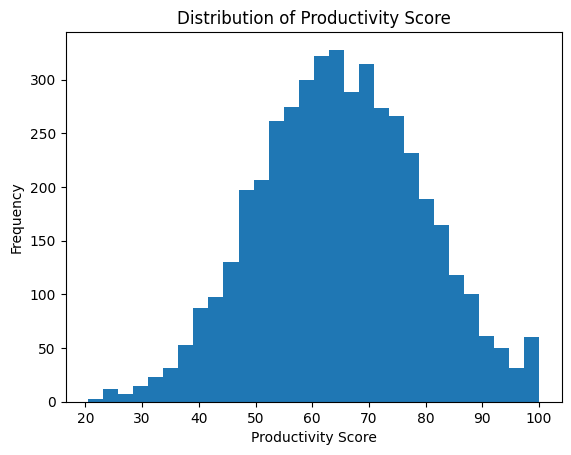

In [20]:
plt.hist(final_df["productivity_score"], bins = 30)
plt.title("Distribution of Productivity Score")
plt.xlabel("Productivity Score")
plt.ylabel("Frequency")
plt.savefig("./data_analysis/histogram_productivity.png", bbox_inches = "tight")
plt.savefig("./data_analysis/histogram_productivity.pdf", bbox_inches = "tight")
plt.show()

### Correlation Heatmap

In [ ]:
plt.figure(figsize=(14, 12))
corr_matrix = final_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            annot_kws={'size': 8}, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('./data_analysis/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()